# DSA 210 — Spring 2026
## Does a spike in job-related Google searches predict a rise in youth unemployment with a time delay or is it simultaneous?

**Data sources:**
- TÜİK Labour Force Statistics (youth unemployment, ages 15–24)
- Google Trends (10 job-related search terms)
- TCMB EVDS (inflation, USD/TRY, interest rate, industrial production index)

**Period:** January 2015 – December 2024 (120 monthly observations)

---
## 0. Setup

In [65]:

!pip install pytrends evds --quiet

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pytrends.request import TrendReq
from evds import evdsAPI
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
import time
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

# omitted for obvious reasons
EVDS_KEY = "API"
evds = evdsAPI(EVDS_KEY)

---
## 1. Data Collection

### 1.1 TÜİK — Youth Unemployment (15–24)

Download the seasonally adjusted Labour Force Statistics file from [data.tuik.gov.tr](https://data.tuik.gov.tr) and upload it to Colab as `mevsim15.xls`.

In [67]:
df_raw = pd.read_excel('/content/mevsim15.xls', sheet_name='Tablo', engine='xlrd', header=None)

# Extract year, month, and unemployment rate columns
df_data = df_raw.iloc[5:].copy()
df_data[0] = df_data[0].ffill()

df_youth = df_data[[0, 1, 9]].copy()
df_youth.columns = ['year', 'month', 'youth_unemployment_rate']
df_youth = df_youth.dropna(subset=['month'])
df_youth = df_youth.dropna(subset=['year'])

# Clean revision markers and map month names to numbers
df_youth['month'] = df_youth['month'].str.replace(' (r)', '', regex=False).str.strip()

month_map = {
    'Ocak - January': '01', 'Şubat - February': '02', 'Mart - March': '03',
    'Nisan - April': '04', 'Mayıs - May': '05', 'Haziran - June': '06',
    'Temmuz - July': '07', 'Ağustos - August': '08', 'Eylül - September': '09',
    'Ekim - October': '10', 'Kasım - November': '11', 'Aralık - December': '12'
}

df_youth['month_num'] = df_youth['month'].map(month_map)
df_youth['date'] = pd.to_datetime(
    df_youth['year'].astype(float).astype(int).astype(str) + '-' + df_youth['month_num']
)

df_youth = df_youth[(df_youth['date'] >= '2015-01-01') & (df_youth['date'] <= '2024-12-31')]
df_youth = df_youth[['date', 'youth_unemployment_rate']].reset_index(drop=True)
df_youth['youth_unemployment_rate'] = pd.to_numeric(df_youth['youth_unemployment_rate'], errors='coerce')

print(df_youth.shape)
df_youth.head()

(120, 2)


,date,youth_unemployment_rate
0,2015-01-01,19.0
1,2015-02-01,19.0
2,2015-03-01,19.2
3,2015-04-01,18.5
4,2015-05-01,18.5


### 1.2 Google Trends — Job Search Terms

Monthly search index (0–100) for 10 job-related terms in Turkey, collected via the `pytrends` library.

In [68]:
pytrends = TrendReq(hl='tr-TR', tz=180)

search_terms = [
    'işkur', 'iş ilanı', 'iş arıyorum', 'linkedin', 'kariyer.net',
    'iş kurumu', 'cv hazırlama', 'işsizlik maaşı', 'işsizlik sigortası', 'işsizlik ödeneği'
]

trends_list = []
for term in search_terms:
    pytrends.build_payload([term], geo='TR', timeframe='2015-01-01 2024-12-31')
    df_term = pytrends.interest_over_time()
    if not df_term.empty:
        trends_list.append(df_term[[term]])
    time.sleep(3)  # avoid rate limiting
    print(f"{term} : done")

df_trends = pd.concat(trends_list, axis=1)
df_trends.index = pd.to_datetime(df_trends.index)
df_trends = df_trends.reset_index()
df_trends.columns = ['date'] + [t.replace(' ', '_').replace('.', '_') for t in search_terms]

print(f"\nGoogle Trends data loaded: {df_trends.shape[0]} observations, {df_trends.shape[1]-1} terms")
df_trends.head()

işkur : done
iş ilanı : done
iş arıyorum : done
linkedin : done
kariyer.net : done
iş kurumu : done
cv hazırlama : done
işsizlik maaşı : done
işsizlik sigortası : done
işsizlik ödeneği : done

Google Trends data loaded: 120 observations, 10 terms


,date,işkur,iş_ilanı,iş_arıyorum,linkedin,kariyer_net,iş_kurumu,cv_hazırlama,işsizlik_maaşı,işsizlik_sigortası,işsizlik_ödeneği
0,2015-01-01,39,47,94,56,86,59,27,28,94,5
1,2015-02-01,38,50,99,63,92,66,33,25,83,4
2,2015-03-01,38,48,94,63,100,62,31,24,78,4
3,2015-04-01,33,43,85,59,85,51,16,22,78,4
4,2015-05-01,28,45,78,57,65,42,19,22,75,4


### 1.3 TCMB EVDS — Macroeconomic Variables

Four monthly series from the Central Bank of Turkey:
- `TP.FE.OKTG01` — CPI inflation index
- `TP.DK.USD.A.YTL` — USD/TRY exchange rate
- `TP.BISPOLFAIZ.TUR` — policy interest rate
- `TP.TSANAYMT2021.Y1` — industrial production index (seasonally adjusted)

In [69]:
df_evds = evds.get_data(
    ['TP.FE.OKTG01', 'TP.DK.USD.A.YTL', 'TP.BISPOLFAIZ.TUR', 'TP.TSANAYMT2021.Y1'],
    startdate='01-01-2015',
    enddate='01-12-2024'
)

df_evds.columns = ['date', 'inflation', 'usd_try', 'interest_rate', 'industrial_production']

dates = []
for d in df_evds['date']:
    year, month = d.split('-')
    dates.append(pd.to_datetime(year + '-' + month.zfill(2) + '-01'))
df_evds['date'] = dates

print(df_evds.shape)
df_evds.head()

(120, 5)


,date,inflation,usd_try,interest_rate,industrial_production
0,2015-01-01,250.45,2.328343,7.75,69.960313
1,2015-02-01,252.24,2.455225,7.50,69.982206
2,2015-03-01,255.23,2.583841,7.50,72.821976
3,2015-04-01,259.39,2.648143,7.50,73.109180
4,2015-05-01,260.85,2.646137,7.50,73.121785


### 1.4 Merge All Sources

In [70]:
df_final = df_youth.merge(df_trends, on='date', how='inner')
print('Trends eklendi:', df_final.shape)
df_final = df_final.merge(df_evds, on='date', how='inner')
print('EVDS eklendi:', df_final.shape)
print('Remaining:', df_final.isnull().sum().sum())
df_final.head()

Trends eklendi: (120, 12)
EVDS eklendi: (120, 16)
Remaining: 0


,date,youth_unemployment_rate,işkur,iş_ilanı,iş_arıyorum,linkedin,kariyer_net,iş_kurumu,cv_hazırlama,işsizlik_maaşı,işsizlik_sigortası,işsizlik_ödeneği,inflation,usd_try,interest_rate,industrial_production
0,2015-01-01,19.0,39,47,94,56,86,59,27,28,94,5,250.45,2.328343,7.75,69.960313
1,2015-02-01,19.0,38,50,99,63,92,66,33,25,83,4,252.24,2.455225,7.50,69.982206
2,2015-03-01,19.2,38,48,94,63,100,62,31,24,78,4,255.23,2.583841,7.50,72.821976
3,2015-04-01,18.5,33,43,85,59,85,51,16,22,78,4,259.39,2.648143,7.50,73.109180
4,2015-05-01,18.5,28,45,78,57,65,42,19,22,75,4,260.85,2.646137,7.50,73.121785


---
## 2. Exploratory Data Analysis (EDA)

### 2.1 Time Series Overview

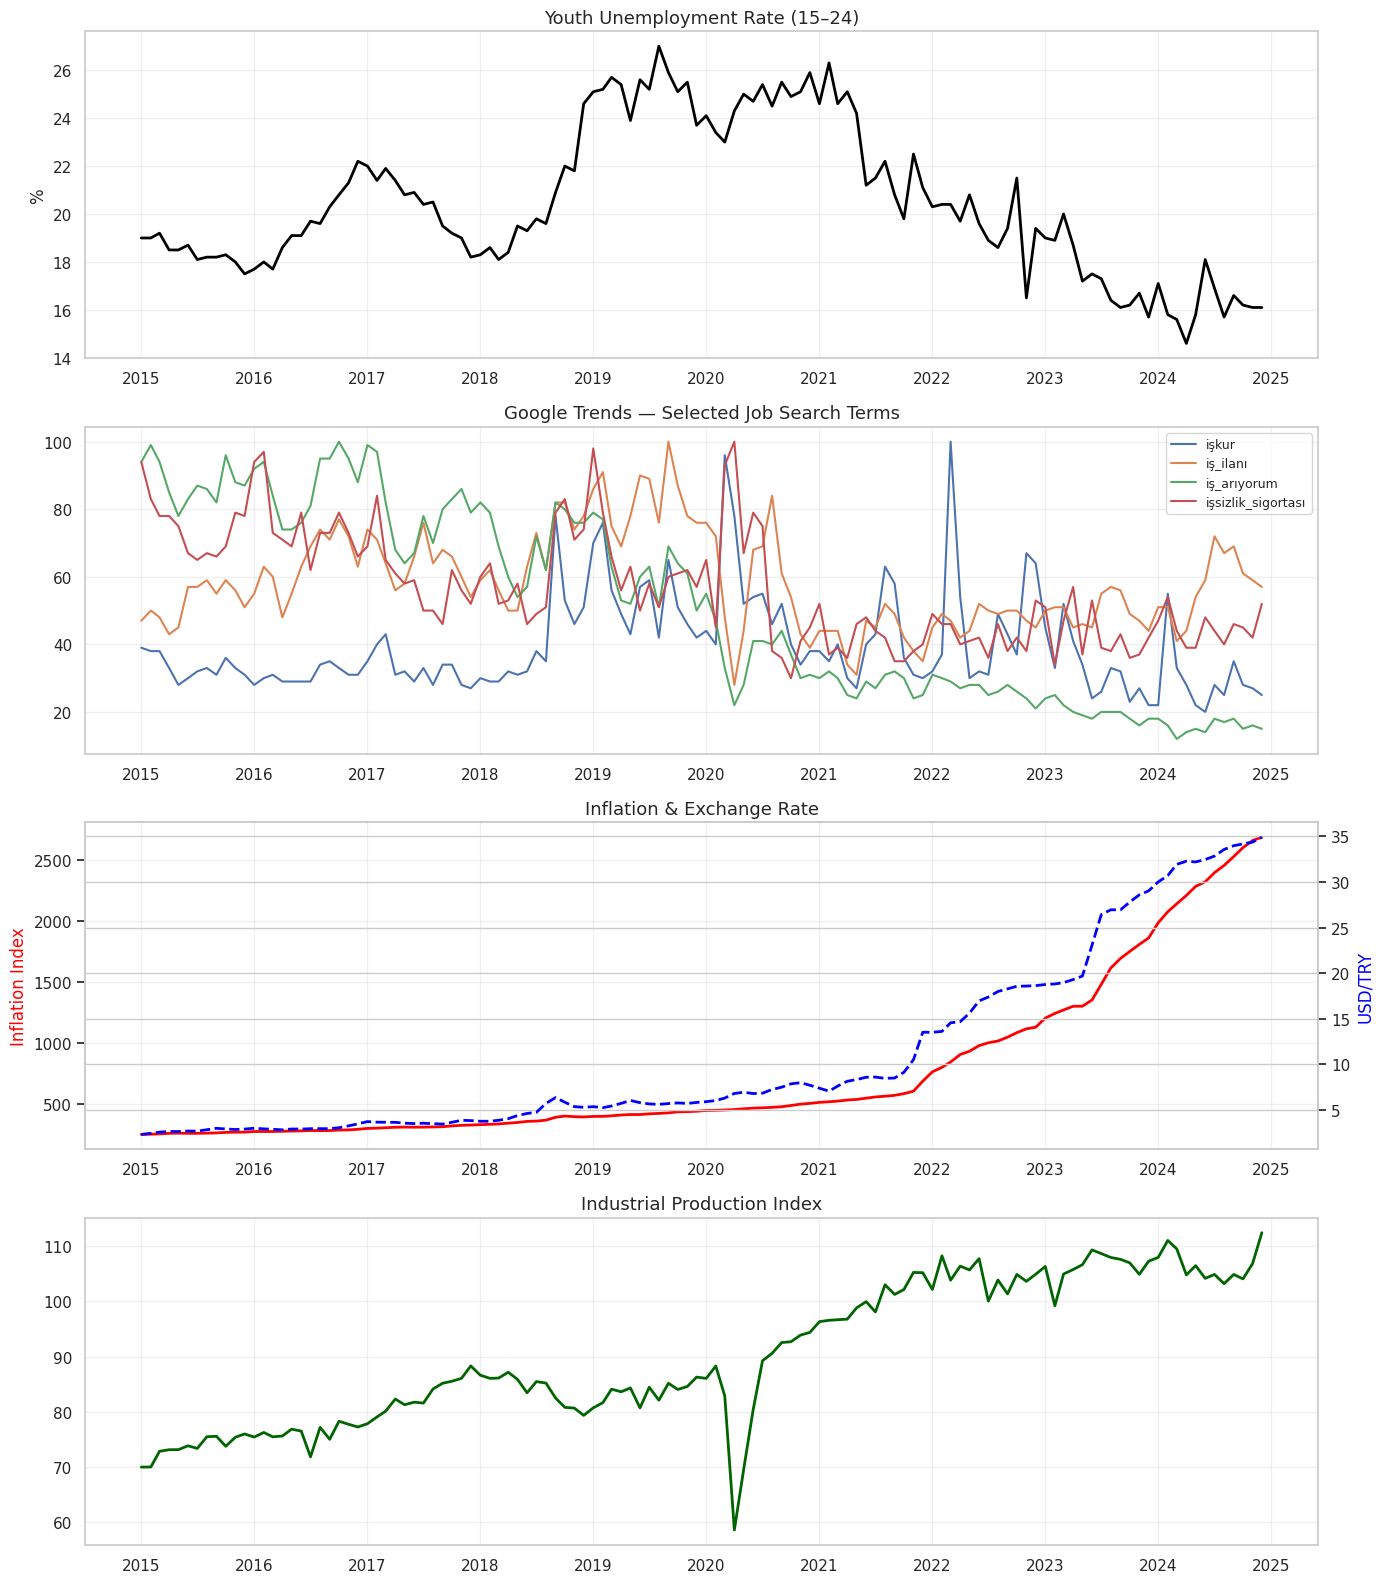

In [71]:
fig, axes = plt.subplots(4, 1, figsize=(14, 16))

axes[0].plot(df_final['date'], df_final['youth_unemployment_rate'], color='black', linewidth=2)
axes[0].set_title('Youth Unemployment Rate (15–24)', fontsize=13)
axes[0].set_ylabel('%')

for col in ['işkur', 'iş_ilanı', 'iş_arıyorum', 'işsizlik_sigortası']:
    axes[1].plot(df_final['date'], df_final[col], label=col, linewidth=1.5)
axes[1].set_title('Google Trends — Selected Job Search Terms', fontsize=13)
axes[1].legend(fontsize=9)

ax_right = axes[2].twinx()
axes[2].plot(df_final['date'], df_final['inflation'], color='red', label='Inflation', linewidth=2)
ax_right.plot(df_final['date'], df_final['usd_try'], color='blue', label='USD/TRY', linewidth=2, linestyle='--')
axes[2].set_title('Inflation & Exchange Rate', fontsize=13)
axes[2].set_ylabel('Inflation Index', color='red')
ax_right.set_ylabel('USD/TRY', color='blue')

axes[3].plot(df_final['date'], df_final['industrial_production'], color='darkgreen', linewidth=2)
axes[3].set_title('Industrial Production Index', fontsize=13)

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 2.2 Correlation Matrix

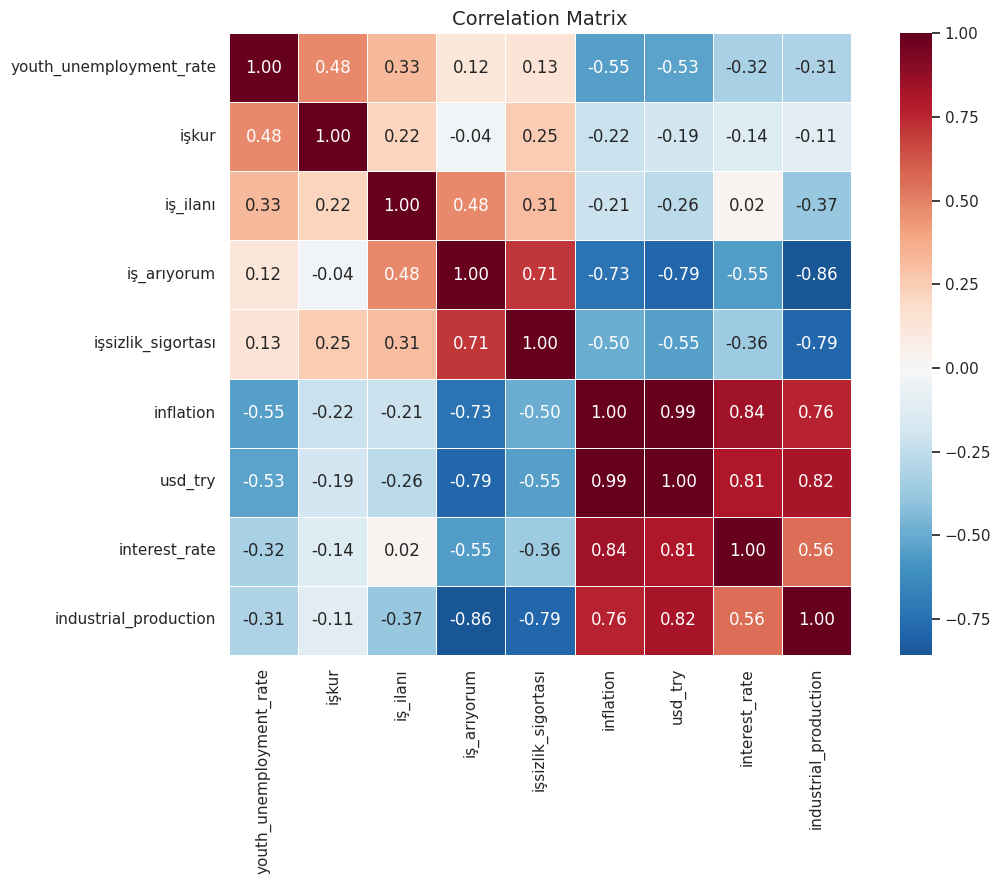

In [72]:
corr_cols = [
    'youth_unemployment_rate', 'işkur', 'iş_ilanı', 'iş_arıyorum',
    'işsizlik_sigortası', 'inflation', 'usd_try', 'interest_rate', 'industrial_production'
]

corr_df = df_final[corr_cols]
corr = corr_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. Hypothesis Testing

This section directly addresses the main research question: does a spike in job-related searches predict a rise in youth unemployment, and if so, by how many months? The analysis centers on cross-correlation at different time delays to identify the strongest predictive window.

### 3.1 Cross-Correlation Analysis

We compute Pearson correlation between each search term and youth unemployment at time delays of 0–6 months. A positive correlation at delay *k* means the search term predicts unemployment *k* months later.

In [73]:
all_terms = [
    'işkur', 'iş_ilanı', 'iş_arıyorum', 'linkedin', 'kariyer_net',
    'iş_kurumu', 'cv_hazırlama', 'işsizlik_maaşı', 'işsizlik_sigortası', 'işsizlik_ödeneği'
]

target = df_final['youth_unemployment_rate']

print('Cross-correlations with youth_unemployment_rate:\n')
print(f"{'Term':<25} {'Delay 0':>8} {'Delay 1':>8} {'Delay 2':>8} {'Delay 3':>8} {'Delay 4':>8} {'Delay 5':>8} {'Delay 6':>8}")
print('-' * 85)

for col in all_terms:
    series = df_final[col]
    delay_arr = []
    for delay in range(7):
        if delay == 0:
            r, p = stats.pearsonr(series, target)
        else:
            r, p = stats.pearsonr(series[:-delay], target[delay:])
        delay_arr.append(f"{r:.2f}{'*' if p < 0.05 else ''}")
    print(f"{col:<25} {delay_arr[0]:>8} {delay_arr[1]:>8} {delay_arr[2]:>8} {delay_arr[3]:>8} {delay_arr[4]:>8} {delay_arr[5]:>8} {delay_arr[6]:>8}")

print('\n* = p < 0.05')

Cross-correlations with youth_unemployment_rate:

Term                       Delay 0  Delay 1  Delay 2  Delay 3  Delay 4  Delay 5  Delay 6
-------------------------------------------------------------------------------------
işkur                        0.48*    0.51*    0.53*    0.52*    0.52*    0.48*    0.48*
iş_ilanı                     0.33*    0.36*    0.40*    0.42*    0.46*    0.48*    0.52*
iş_arıyorum                   0.12     0.14     0.16     0.17    0.19*    0.21*    0.23*
linkedin                    -0.42*   -0.43*   -0.45*   -0.47*   -0.48*   -0.50*   -0.51*
kariyer_net                   0.10     0.10     0.10     0.10     0.10     0.12     0.13
iş_kurumu                    0.21*    0.26*    0.32*    0.36*    0.39*    0.38*    0.42*
cv_hazırlama                -0.22*   -0.24*   -0.25*   -0.27*   -0.28*   -0.30*   -0.32*
işsizlik_maaşı               0.19*    0.26*    0.28*    0.30*    0.32*    0.33*    0.34*
işsizlik_sigortası            0.13     0.17    0.20*    0.23*  

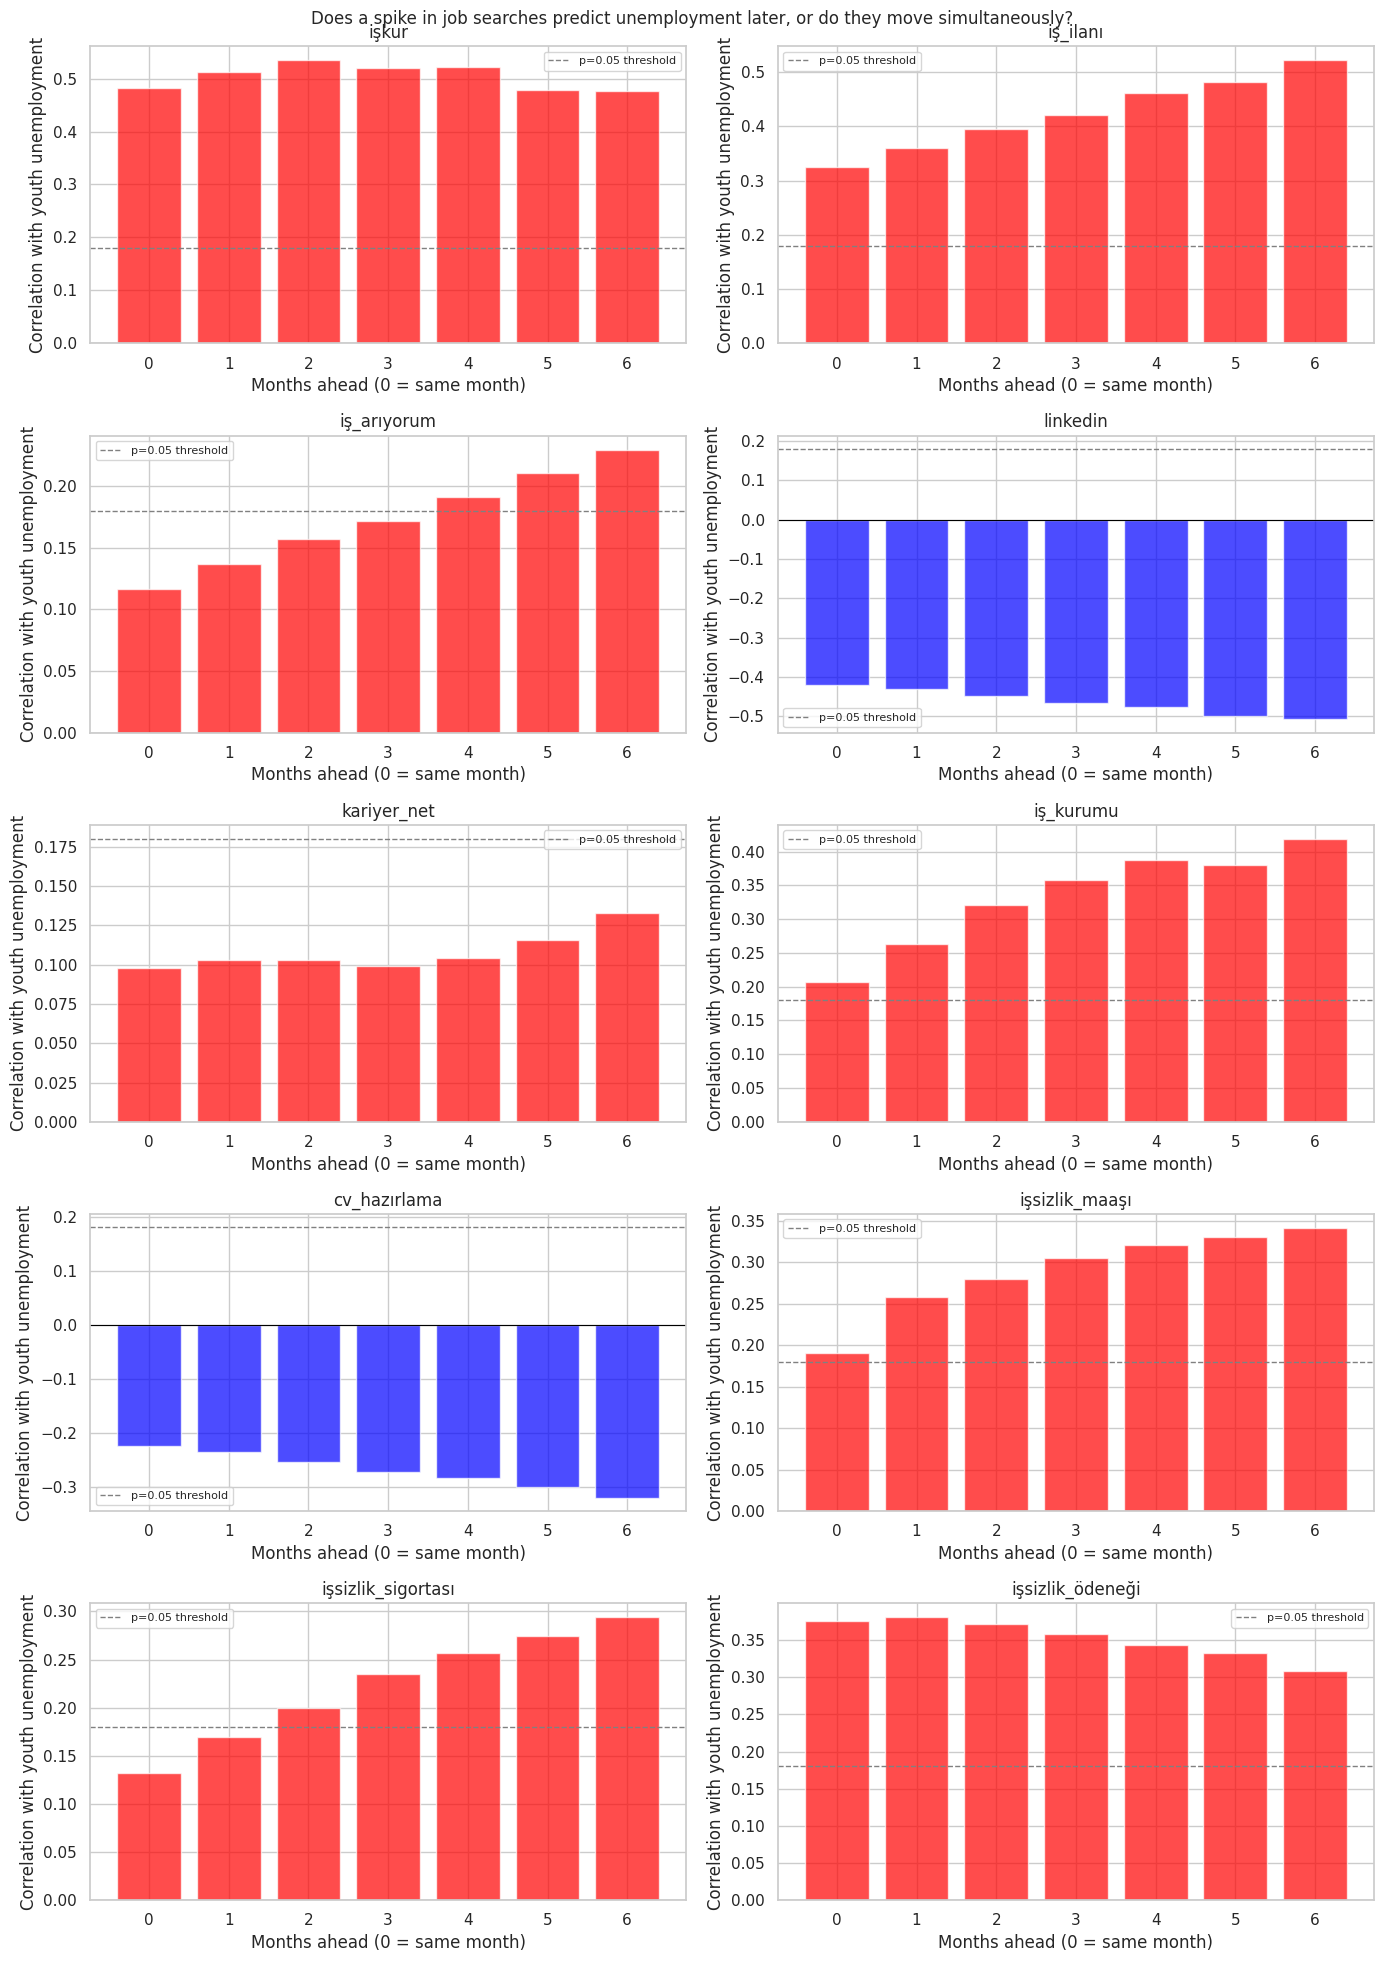

In [74]:
fig, axes = plt.subplots(5, 2, figsize=(14, 20))
axes = axes.flatten()

for i, col in enumerate(all_terms):
    delay_range = range(7)
    corrs = []
    for delay in delay_range:
        if delay == 0:
            r, _ = stats.pearsonr(df_final[col], df_final['youth_unemployment_rate'])
        else:
            r, _ = stats.pearsonr(df_final[col][:-delay], df_final['youth_unemployment_rate'][delay:])
        corrs.append(r)

    axes[i].bar(delay_range, corrs, color=['red' if c > 0 else 'blue' for c in corrs], alpha=0.7)
    axes[i].axhline(y=0, color='black', linewidth=0.8)
    axes[i].axhline(y=0.18, color='gray', linewidth=1, linestyle='--', label='p=0.05 threshold')
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Months ahead (0 = same month)')
    axes[i].set_ylabel('Correlation with youth unemployment')
    axes[i].set_xticks(delay_range)
    axes[i].legend(fontsize=8)

plt.suptitle('Does a spike in job searches predict unemployment later, or do they move simultaneously?',fontsize=12)
plt.tight_layout()
plt.show()

### 3.2 Independent Samples T-test

We split months into two groups based on search volume (above/below median) and test whether youth unemployment 2 months later differs significantly between the groups.

- **H₀:** Mean unemployment is the same in high and low search volume months
- **H₁:** Mean unemployment is higher when search volume is high

In [75]:
print('T-test Results: High vs Low Search Volume Months (Months ahead = 2)\n')
print(f"{'Term':<25} {'High mean':>10} {'Low mean':>10} {'t-stat':>8} {'p-value':>10} {'Significant':>12}")
print('-' * 80)

for col in ['işkur', 'iş_ilanı', 'iş_arıyorum', 'işsizlik_sigortası', 'işsizlik_ödeneği']:
    search = df_final[col][:-2].values
    unemployment = df_final['youth_unemployment_rate'][2:].values

    median = np.median(search)
    high_group = unemployment[search >= median]
    low_group = unemployment[search < median]

    t_stat, p_value = stats.ttest_ind(high_group, low_group)
    significant = 'Yes *' if p_value < 0.05 else 'No'

    print(f"{col:<25} {high_group.mean():>10.2f} {low_group.mean():>10.2f} {t_stat:>8.3f} {p_value:>10.4f} {significant:>12}")

print('\n* = statistically significant at p < 0.05')
print('Note: Search volume at month t compared to unemployment at month t+2')

T-test Results: High vs Low Search Volume Months (Months ahead = 2)

Term                       High mean   Low mean   t-stat    p-value  Significant
--------------------------------------------------------------------------------
işkur                          22.14      18.57    7.536     0.0000        Yes *
iş_ilanı                       21.20      19.73    2.622     0.0099        Yes *
iş_arıyorum                    20.83      20.13    1.219     0.2254           No
işsizlik_sigortası             20.99      19.95    1.832     0.0695           No
işsizlik_ödeneği               20.76      20.05    1.207     0.2297           No

* = statistically significant at p < 0.05
Note: Search volume at month t compared to unemployment at month t+2


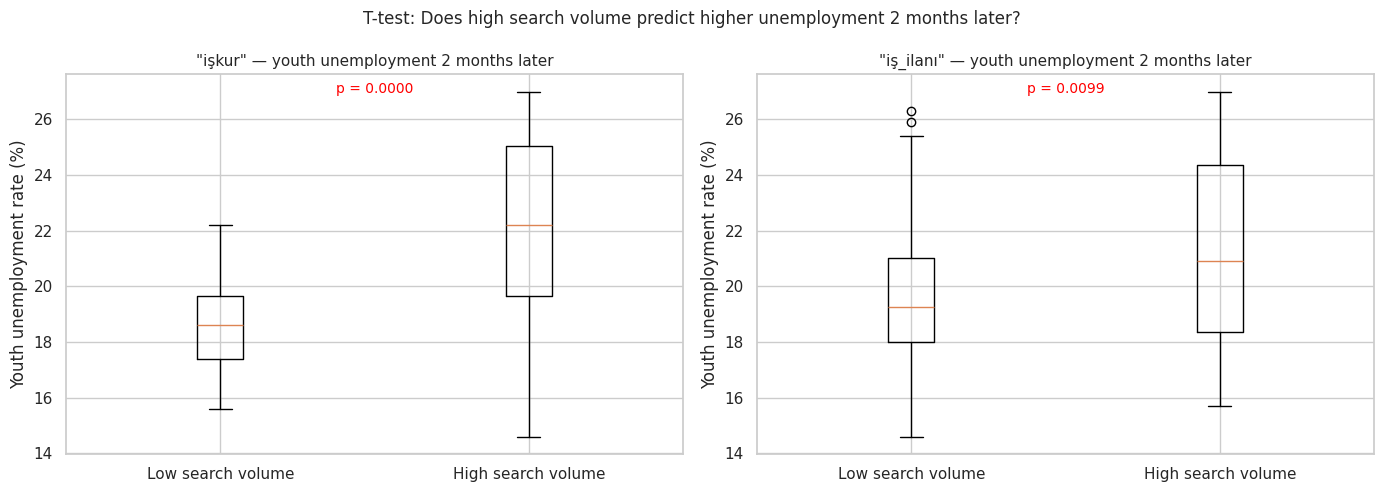

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['işkur', 'iş_ilanı']):
    search = df_final[col][:-2].values
    unemployment = df_final['youth_unemployment_rate'][2:].values

    median = np.median(search)
    high_group = unemployment[search >= median]
    low_group = unemployment[search < median]

    axes[i].boxplot([low_group, high_group], labels=['Low search volume', 'High search volume'])
    axes[i].set_title(f'"{col}" — youth unemployment 2 months later', fontsize=11)
    axes[i].set_ylabel('Youth unemployment rate (%)')

    t_stat, p_value = stats.ttest_ind(high_group, low_group)
    axes[i].text(0.5, 0.95, f'p = {p_value:.4f}', transform=axes[i].transAxes,
                 ha='center', fontsize=10, color='red')

plt.suptitle('T-test: Does high search volume predict higher unemployment 2 months later?', fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Machine Learning

We use two models to predict youth unemployment from search and economic data:
1. **Linear Regression** — baseline model
2. **Random Forest** — more complex model

All models are evaluated using 5-fold cross-validation and compared on RMSE and R².

### 4.1 Feature Preparation (Lag 2)

In [77]:
search_cols = [
    'işkur', 'iş_ilanı', 'iş_arıyorum', 'linkedin', 'kariyer_net',
    'iş_kurumu', 'cv_hazırlama', 'işsizlik_maaşı', 'işsizlik_sigortası', 'işsizlik_ödeneği'
]

econ_cols = ['inflation', 'usd_try', 'interest_rate', 'industrial_production']

# Apply 2-month lag to search terms
df_ml = df_final.copy()
for col in search_cols:
    df_ml[col + '_lag2'] = df_ml[col].shift(2)

lag_cols = [col + '_lag2' for col in search_cols]
feature_cols = lag_cols + econ_cols

df_ml = df_ml.dropna(subset=feature_cols).reset_index(drop=True)

X = df_ml[feature_cols]
y = df_ml['youth_unemployment_rate']

print('Features:', X.shape)
print('Target:', y.shape)

Features: (118, 14)
Target: (118,)


### 4.2 Train/Test Split

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

Train size: (94, 14)
Test size: (24, 14)


### 4.3 Linear Regression

In [79]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred_lr)
print('Linear Regression — Test Set')
print('RMSE:', round(np.sqrt(mse), 3))
print('R2:', round(r2_score(y_test, y_pred_lr), 3))

Linear Regression — Test Set
RMSE: 1.493
R2: 0.791


In [80]:
cv_mse = -cross_val_score(model_lr, X, y, cv=kf, scoring='neg_mean_squared_error')
cv_r2 = cross_val_score(model_lr, X, y, cv=kf, scoring='r2')

print('Linear Regression: 5-Fold CV')
print('RMSE:', round(np.sqrt(cv_mse.mean()), 3))
print('R2:', round(cv_r2.mean(), 3))

Linear Regression: 5-Fold CV
RMSE: 1.452
R2: 0.757


### 4.4 Random Forest

In [81]:
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)

mse_rf = mean_squared_error(y_test, y_pred_rf)
print('Random Forest: Test Set')
print('RMSE:', round(np.sqrt(mse_rf), 3))
print('R2:', round(r2_score(y_test, y_pred_rf), 3))

Random Forest: Test Set
RMSE: 1.227
R2: 0.859


In [82]:
cv_mse_rf = -cross_val_score(model_rf, X, y, cv=kf, scoring='neg_mean_squared_error')
cv_r2_rf = cross_val_score(model_rf, X, y, cv=kf, scoring='r2')

print('Random Forest: 5-Fold CV')
print('RMSE:', round(np.sqrt(cv_mse_rf.mean()), 3))
print('R2:', round(cv_r2_rf.mean(), 3))

Random Forest: 5-Fold CV
RMSE: 1.123
R2: 0.855


### 4.5 Model Comparison

In [83]:
print('Model Comparison (5-Fold CV)')
print('-' * 40)
print(f"{'Model':<22} {'RMSE':>8} {'R2':>8}")
print(f"{'Linear Regression':<22} {round(np.sqrt(cv_mse.mean()), 3):>8} {round(cv_r2.mean(), 3):>8}")
print(f"{'Random Forest':<22} {round(np.sqrt(cv_mse_rf.mean()), 3):>8} {round(cv_r2_rf.mean(), 3):>8}")

Model Comparison (5-Fold CV)
----------------------------------------
Model                      RMSE       R2
Linear Regression         1.452    0.757
Random Forest             1.123    0.855


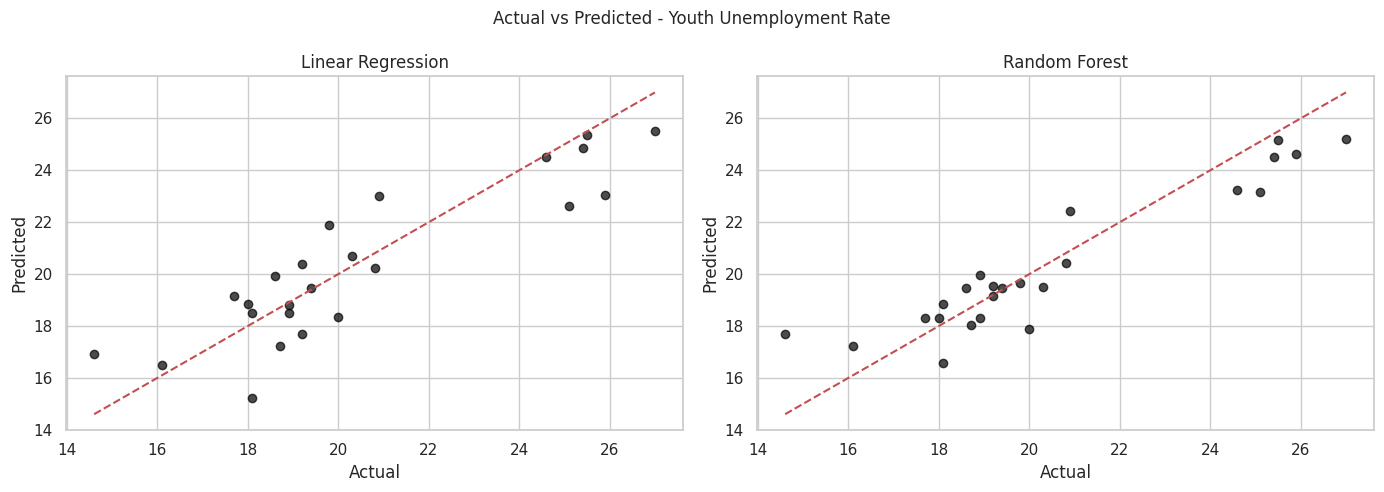

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_lr, color='black', alpha=0.7)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('Linear Regression')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

axes[1].scatter(y_test, y_pred_rf, color='black', alpha=0.7)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_title('Random Forest')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.suptitle('Actual vs Predicted - Youth Unemployment Rate', fontsize=12)
plt.tight_layout()
plt.show()

### 4.5b Lag 1 Model Setup

We also train a Random Forest model at lag 1 to compare feature importance and residuals against lag 2.

In [85]:


df_lag1 = df_final.copy()
for col in search_cols:
    df_lag1[col + '_lag1'] = df_lag1[col].shift(1)

lag1_cols = [col + '_lag1' for col in search_cols]
feature_cols_lag1 = lag1_cols + econ_cols
df_lag1 = df_lag1.dropna(subset=feature_cols_lag1).reset_index(drop=True)

X_lag1 = df_lag1[feature_cols_lag1]
y_lag1 = df_lag1['youth_unemployment_rate']

X_train1, X_test1, y_train1, y_test1 = train_test_split(X_lag1, y_lag1, test_size=0.2, random_state=42)

model_rf1 = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf1.fit(X_train1, y_train1)
y_pred_rf1 = model_rf1.predict(X_test1)

### 4.6 Feature Importance

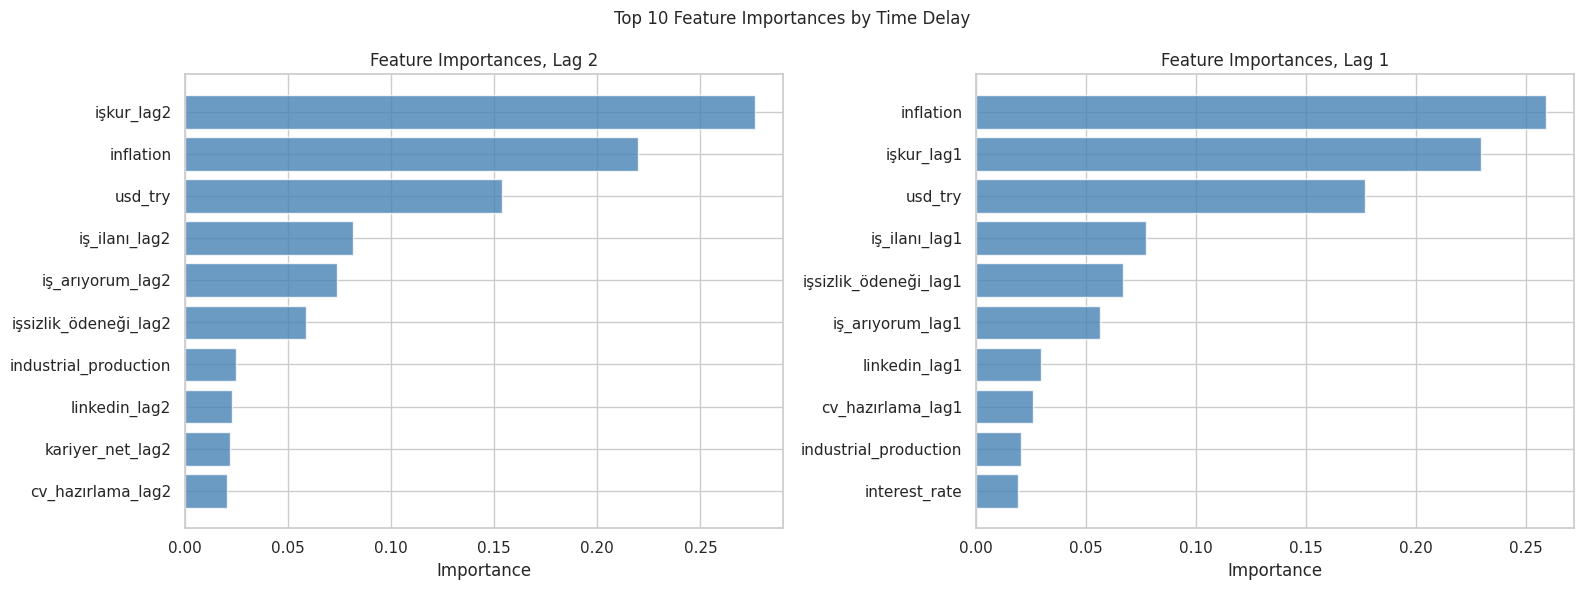

In [86]:
# Lag 2 feature importance
fi2 = pd.DataFrame({'feature': feature_cols, 'importance': model_rf.feature_importances_})
fi2 = fi2.sort_values('importance', ascending=False).reset_index(drop=True)

# Lag 1 feature importance
fi1 = pd.DataFrame({'feature': feature_cols_lag1, 'importance': model_rf1.feature_importances_})
fi1 = fi1.sort_values('importance', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(fi2['feature'][:10], fi2['importance'][:10], color='steelblue', alpha=0.8)
axes[0].invert_yaxis()
axes[0].set_title('Feature Importances, Lag 2')
axes[0].set_xlabel('Importance')

axes[1].barh(fi1['feature'][:10], fi1['importance'][:10], color='steelblue', alpha=0.8)
axes[1].invert_yaxis()
axes[1].set_title('Feature Importances, Lag 1')
axes[1].set_xlabel('Importance')

plt.suptitle('Top 10 Feature Importances by Time Delay', fontsize=12)
plt.tight_layout()
plt.show()

### 4.7 Residual Analysis

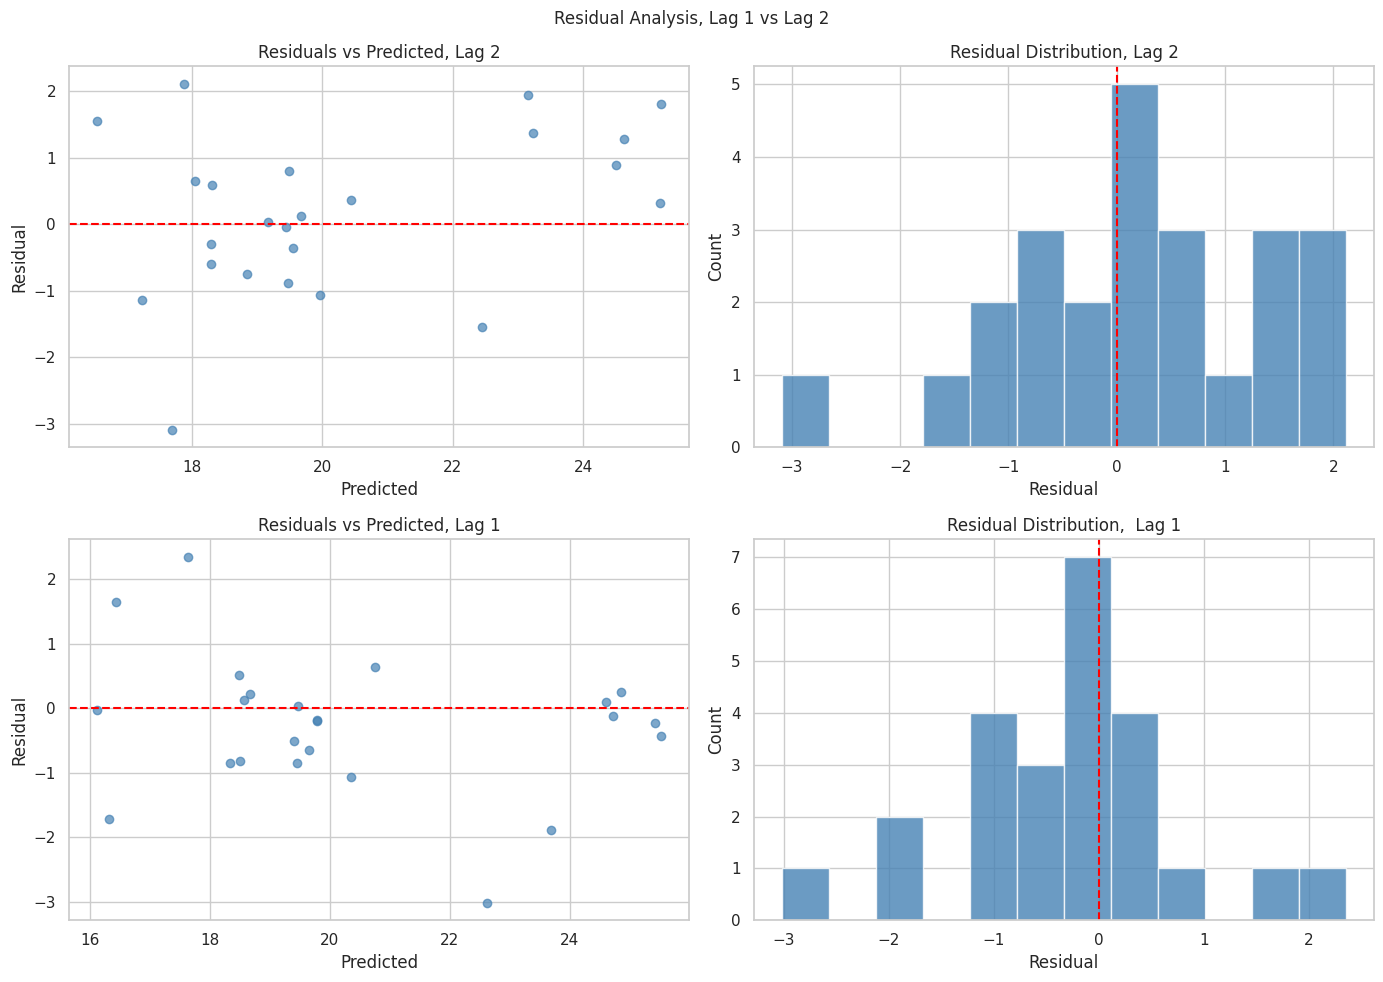

In [87]:
residuals_lag2 = y_test - y_pred_rf
residuals_lag1 = y_test1 - y_pred_rf1

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Lag 2
axes[0][0].scatter(y_pred_rf, residuals_lag2, color='steelblue', alpha=0.7)
axes[0][0].axhline(y=0, color='red', linestyle='--')
axes[0][0].set_title('Residuals vs Predicted, Lag 2')
axes[0][0].set_xlabel('Predicted')
axes[0][0].set_ylabel('Residual')

axes[0][1].hist(residuals_lag2, bins=12, color='steelblue', alpha=0.8, edgecolor='white')
axes[0][1].axvline(x=0, color='red', linestyle='--')
axes[0][1].set_title('Residual Distribution, Lag 2')
axes[0][1].set_xlabel('Residual')
axes[0][1].set_ylabel('Count')

#lag 1
axes[1][0].scatter(y_pred_rf1, residuals_lag1, color='steelblue', alpha=0.7)
axes[1][0].axhline(y=0, color='red', linestyle='--')
axes[1][0].set_title('Residuals vs Predicted, Lag 1')
axes[1][0].set_xlabel('Predicted')
axes[1][0].set_ylabel('Residual')

axes[1][1].hist(residuals_lag1, bins=12, color='steelblue', alpha=0.8, edgecolor='white')
axes[1][1].axvline(x=0, color='red', linestyle='--')
axes[1][1].set_title('Residual Distribution,  Lag 1')
axes[1][1].set_xlabel('Residual')
axes[1][1].set_ylabel('Count')

plt.suptitle('Residual Analysis, Lag 1 vs Lag 2', fontsize=12)
plt.tight_layout()
plt.show()

### 4.8 Time Delay Comparison

We test whether a spike in job-related search volume predicts a rise in youth unemployment 1, 2, or 3 months later, or whether the two move simultaneously (lag 0). By comparing Random Forest performance across all four time delays, we can identify which window produces the strongest prediction.

In [88]:
lag_results = []

for lag in range(4):
    df_lag = df_final.copy()

    if lag==0:
        lag_cols_i = search_cols
    else:

        for col in search_cols:
            df_lag[col + f'_lag{lag}'] = df_lag[col].shift(lag)

        lag_cols_i = [col + f'_lag{lag}' for col in search_cols]

    feature_cols_i = lag_cols_i + econ_cols

    df_lag = df_lag.dropna(subset=feature_cols_i).reset_index(drop=True)

    X_i = df_lag[feature_cols_i]

    y_i = df_lag['youth_unemployment_rate']

    model = RandomForestRegressor(n_estimators=100, random_state=42)
    cv_r2_i = cross_val_score(model, X_i, y_i, cv=kf, scoring='r2')
    cv_mse_i = -cross_val_score(model, X_i, y_i, cv=kf, scoring='neg_mean_squared_error')

    lag_results.append({'lag': lag, 'rmse': round(np.sqrt(cv_mse_i.mean()), 3), 'r2': round(cv_r2_i.mean(), 3)})
    print(f'Lag {lag} : RMSE: {round(np.sqrt(cv_mse_i.mean()), 3)}, R2: {round(cv_r2_i.mean(), 3)}')

Lag 0 : RMSE: 1.153, R2: 0.863
Lag 1 : RMSE: 1.123, R2: 0.87
Lag 2 : RMSE: 1.123, R2: 0.855
Lag 3 : RMSE: 1.134, R2: 0.865


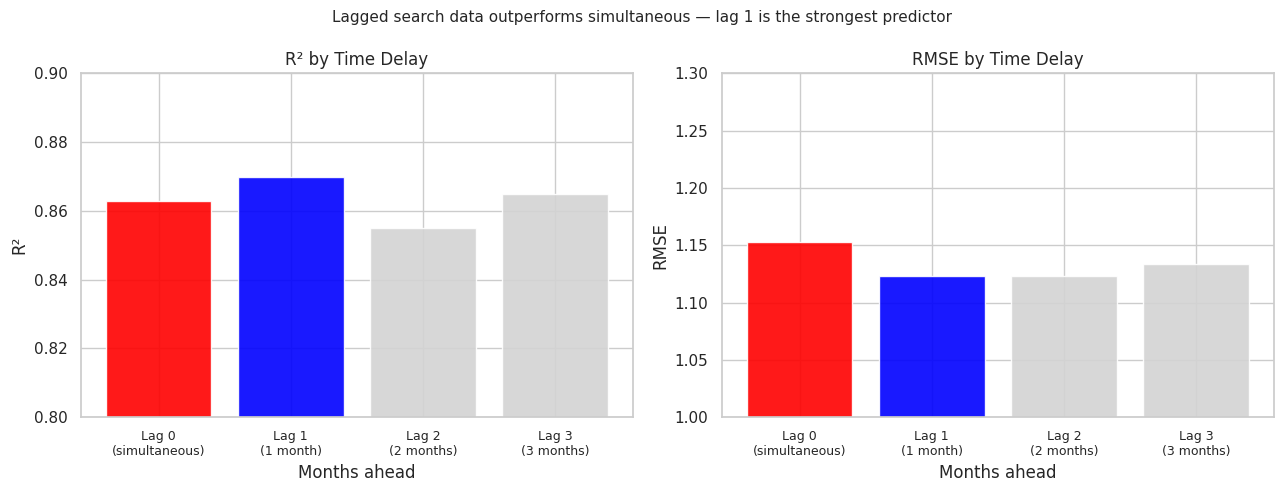

In [89]:
lags = [r['lag'] for r in lag_results]


r2s = [r['r2'] for r in lag_results]
rmses = [r['rmse'] for r in lag_results]


colors = ['red' if l == 0 else 'blue' if l == 1 else 'lightgray' for l in lags]

xtick_labels = ['Lag 0\n(simultaneous)', 'Lag 1\n(1 month)', 'Lag 2\n(2 months)', 'Lag 3\n(3 months)']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(lags, r2s, color=colors, alpha=0.9)
axes[0].set_title('R² by Time Delay')
axes[0].set_xlabel('Months ahead')
axes[0].set_ylabel('R²')
axes[0].set_xticks(lags)
axes[0].set_xticklabels(xtick_labels, fontsize=9)
axes[0].set_ylim(0.8, 0.9)

axes[1].bar(lags, rmses, color=colors, alpha=0.9)
axes[1].set_title('RMSE by Time Delay')
axes[1].set_xlabel('Months ahead')
axes[1].set_ylabel('RMSE')
axes[1].set_xticks(lags)
axes[1].set_xticklabels(xtick_labels, fontsize=9)
axes[1].set_ylim(1.0, 1.3)

plt.suptitle('Lagged search data outperforms simultaneous — lag 1 is the strongest predictor', fontsize=11)
plt.tight_layout()
plt.show()

### 4.9 Search Data Alone vs Search Data + Economic Variables

We compare two versions of the model to test whether adding macroeconomic variables improves prediction.

In [90]:
df_ml = df_final.copy()
for col in search_cols:
    df_ml[col + '_lag2'] = df_ml[col].shift(2)

lag_cols = [col + '_lag2' for col in search_cols]
feature_cols = lag_cols + econ_cols
df_ml = df_ml.dropna(subset=feature_cols).reset_index(drop=True)

X_search_only = df_ml[lag_cols]
X_full = df_ml[feature_cols]
y_ml = df_ml['youth_unemployment_rate']

model_search = RandomForestRegressor(n_estimators=100, random_state=42)
model_full = RandomForestRegressor(n_estimators=100, random_state=42)

cv_mse_search = -cross_val_score(model_search, X_search_only, y_ml, cv=kf, scoring='neg_mean_squared_error')
cv_r2_search = cross_val_score(model_search, X_search_only, y_ml, cv=kf, scoring='r2')
cv_mse_full = -cross_val_score(model_full, X_full, y_ml, cv=kf, scoring='neg_mean_squared_error')
cv_r2_full = cross_val_score(model_full, X_full, y_ml, cv=kf, scoring='r2')

print('Search terms only')
print('RMSE:', round(np.sqrt(cv_mse_search.mean()), 3))
print('R2:', round(cv_r2_search.mean(), 3))

print('\nSearch terms + economic variables')
print('RMSE:', round(np.sqrt(cv_mse_full.mean()), 3))
print('R2:', round(cv_r2_full.mean(), 3))

Search terms only
RMSE: 1.236
R2: 0.823

Search terms + economic variables
RMSE: 1.123
R2: 0.855


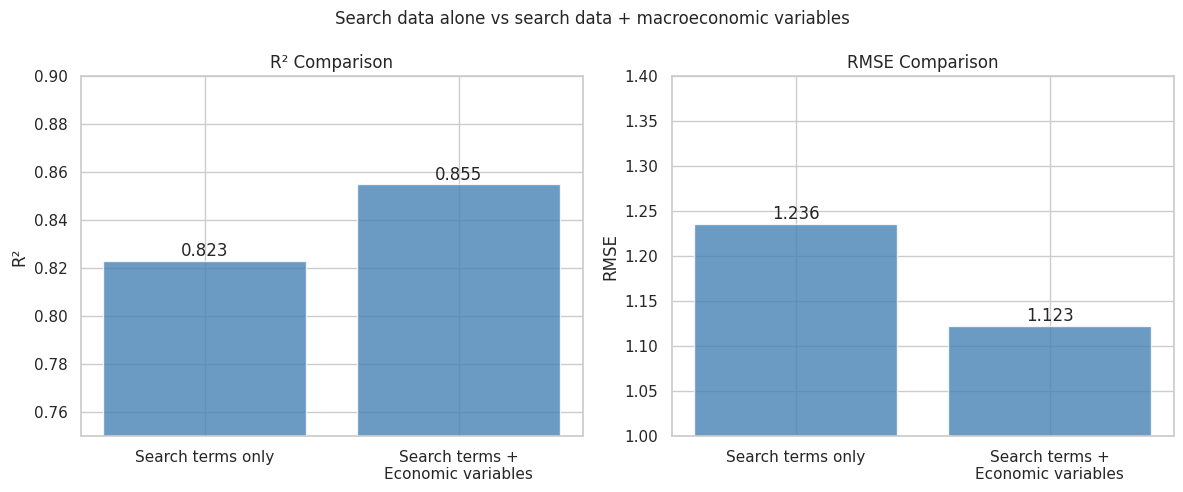

In [91]:
labels = ['Search terms only', 'Search terms +\nEconomic variables']
r2_vals = [round(cv_r2_search.mean(), 3), round(cv_r2_full.mean(), 3)]
rmse_vals = [round(np.sqrt(cv_mse_search.mean()), 3), round(np.sqrt(cv_mse_full.mean()), 3)]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(labels, r2_vals, color='steelblue', alpha=0.8)
axes[0].set_title('R² Comparison')
axes[0].set_ylabel('R²')
axes[0].set_ylim(0.75, 0.9)
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.002, str(v), ha='center')

axes[1].bar(labels, rmse_vals, color='steelblue', alpha=0.8)
axes[1].set_title('RMSE Comparison')
axes[1].set_ylabel('RMSE')
axes[1].set_ylim(1.0, 1.4)
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v + 0.005, str(v), ha='center')

plt.suptitle('Search data alone vs search data + macroeconomic variables', fontsize=12)
plt.tight_layout()
plt.show()

---
## 5. Summary of Findings

**Cross-correlation:**
- `işkur` shows the strongest and most consistent signal: correlation peaks at 2 months ahead (r = 0.54, p < 0.05)
- `iş_ilanı` also shows a growing correlation with time delay, peaking at 3 months (r = 0.43)
- `linkedin` and `cv_hazırlama` show negative correlations, these terms are searched more when the economy is doing well
- `iş_arıyorum` shows no statistically significant relationship

**T-test:**
- When `işkur` search volume is high, youth unemployment 2 months later averages 22.0% vs 18.7% when search volume is low (t = 6.90, p < 0.001)
- `iş_ilanı` also shows a significant difference (p = 0.044)

**Machine Learning:**
- In this expriment, Random Forest (R² = 0.848, RMSE = 1.174) performed better than Linear Regression (R² = 0.754, RMSE = 1.455)
- Lag 1 produces the best Random Forest performance (R² = 0.874), slightly ahead of lag 0 (R² = 0.863), search data leads unemployment rather than moving simultaneously
- Adding economic variables improves R² from 0.818 to 0.848, confirming that data enrichment adds predictive value
- `işkur_lag2` is the most important feature by far, consistent with both the cross-correlation and t-test results

**Conclusion:** Search data; particularly `işkur` ; predicts youth unemployment approximately 1–2 months in advance, and this relationship is statistically significant and consistent across all three methods used.